# Exploring the Tabular Data for HECKTOR 2026



In [96]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [97]:
rawDF = pd.read_csv('../Data/HECKTOR_2026_training_data.csv')
rawDF.head()

,PatientID,CenterID,Age,Gender,Tobacco Consumption,Alcohol Consumption,Performance Status,Treatment,HPV Status,Relapse,RFS,T-stage,N-stage
0,CHUM-001,1.0,82.0,1.0,NaN,NaN,NaN,1.0,NaN,0.0,1704.0,T2,N2
1,CHUM-002,1.0,73.0,1.0,NaN,NaN,NaN,1.0,NaN,1.0,439.0,T3,N1
2,CHUM-006,1.0,65.0,1.0,NaN,NaN,NaN,1.0,NaN,0.0,1186.0,T2,N2
3,CHUM-007,1.0,70.0,0.0,NaN,NaN,NaN,0.0,NaN,0.0,1702.0,T2,N2
4,CHUM-008,1.0,67.0,0.0,NaN,NaN,NaN,1.0,NaN,0.0,1499.0,T2,N2


In [98]:
rawDF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 782 entries, 0 to 781
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   PatientID            782 non-null    object 
 1   CenterID             782 non-null    float64
 2   Age                  782 non-null    float64
 3   Gender               782 non-null    float64
 4   Tobacco Consumption  522 non-null    float64
 5   Alcohol Consumption  516 non-null    float64
 6   Performance Status   468 non-null    float64
 7   Treatment            763 non-null    float64
 8   HPV Status           597 non-null    float64
 9   Relapse              727 non-null    float64
 10  RFS                  727 non-null    float64
 11  T-stage              778 non-null    object 
 12  N-stage              782 non-null    object 
dtypes: float64(10), object(3)
memory usage: 79.6+ KB


In [99]:
rawDF['Performance Status'].value_counts()

Performance Status
0.0    226
1.0    208
2.0     23
3.0      7
4.0      4
Name: count, dtype: int64

In [100]:
rawDF["Treatment"].value_counts()
rawDF["HPV Status"].value_counts()

HPV Status
1.0    533
0.0     64
Name: count, dtype: int64

In [101]:
rawDF.describe()

,CenterID,Age,Gender,Tobacco Consumption,Alcohol Consumption,Performance Status,Treatment,HPV Status,Relapse,RFS
count,782.000000,782.000000,782.000000,522.000000,516.000000,468.000000,763.000000,597.000000,727.000000,727.000000
mean,4.335038,59.987468,0.835038,0.461686,0.637597,0.621795,0.836173,0.892797,0.203576,1638.778542
std,1.514006,9.211646,0.371383,0.499008,0.481161,0.725872,0.370361,0.309630,0.402935,1200.289138
min,1.000000,32.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.000000
25%,3.000000,53.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,715.000000
50%,5.000000,59.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1295.000000
75%,5.000000,66.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,2545.500000
max,8.000000,90.000000,1.000000,1.000000,1.000000,4.000000,1.000000,1.000000,1.000000,5888.000000


In [102]:
rawDF.isnull().sum()

PatientID                0
CenterID                 0
Age                      0
Gender                   0
Tobacco Consumption    260
Alcohol Consumption    266
Performance Status     314
Treatment               19
HPV Status             185
Relapse                 55
RFS                     55
T-stage                  4
N-stage                  0
dtype: int64

## Visualizations

Quick plots to see what we're working with. Main focus: missing values and label balance.

### Missing Values per column

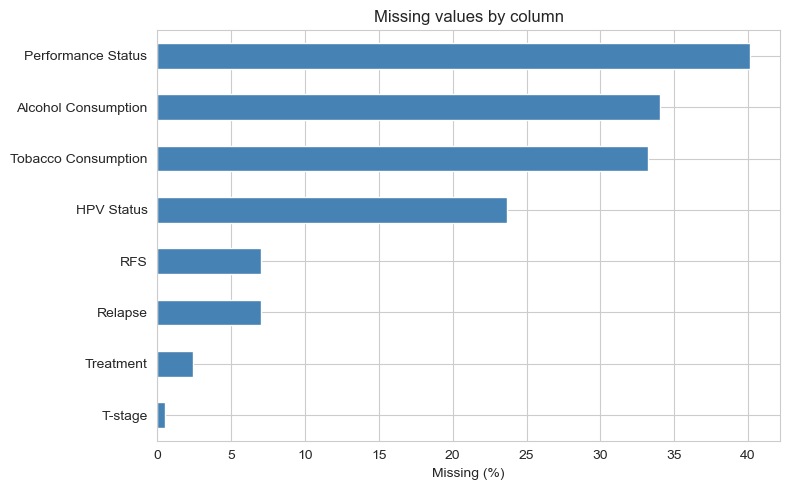

Rows: 782
T-stage                 0.5
Treatment               2.4
Relapse                 7.0
RFS                     7.0
HPV Status             23.7
Tobacco Consumption    33.2
Alcohol Consumption    34.0
Performance Status     40.2
dtype: float64


In [103]:
# Missing values per column (%)
missing_pct = (rawDF.isnull().mean() * 100).sort_values(ascending=True)
missing_pct = missing_pct[missing_pct > 0]

plt.figure(figsize=(8, 5))
missing_pct.plot(kind="barh", color="steelblue")
plt.xlabel("Missing (%)")
plt.title("Missing values by column")
plt.tight_layout()
plt.show()

print("Rows:", len(rawDF))
print(missing_pct.round(1))

There are a lot of performance status missing columns. We cannot simply drop them it seems, but we can confirm the damage that would be done if we actually do.

In [104]:
# How complete is each row?
clinical_cols = [
    "Tobacco Consumption", "Alcohol Consumption",
    "Performance Status", "Treatment", "HPV Status",
]

all_clinical = rawDF[clinical_cols].notna().all(axis=1).sum()
all_tn = rawDF[["T-stage", "N-stage"]].notna().all(axis=1).sum()
all_rfs = rawDF[["Relapse", "RFS"]].notna().all(axis=1).sum()

summary = pd.Series({
    "All clinical features present": all_clinical,
    "T-stage + N-stage present": all_tn,
    "Relapse + RFS present": all_rfs,
    "Total patients": len(rawDF),
})

print(summary)
print()
print("Usable for Task 2 (TN staging):", all_tn)
print("Usable for Task 3 (prognosis):", all_rfs)

All clinical features present    451
T-stage + N-stage present        778
Relapse + RFS present            727
Total patients                   782
dtype: int64

Usable for Task 2 (TN staging): 778
Usable for Task 3 (prognosis): 727


Yeah, only 451 rows where we have data present. That is not enough, and takes away too much data.

### Missing Values Correlation with Centre ID (Hospital)

Checking to see if there is any reason as to why data is missing, maybe leading to an insight on how to solve them.

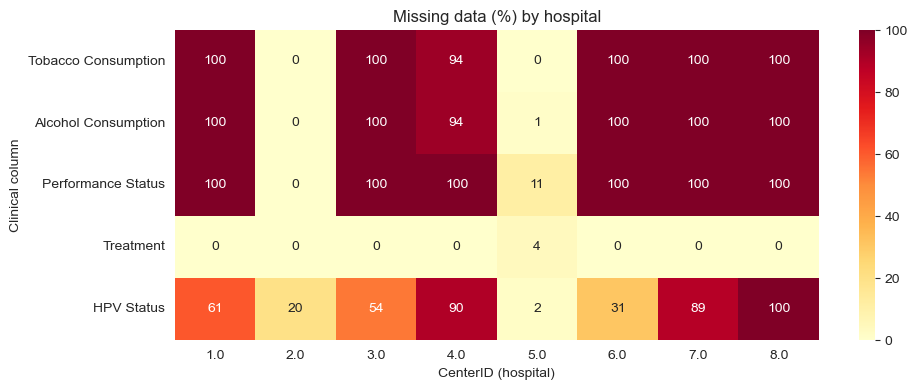

In [105]:
# Are certain hospitals missing more clinical data than others?
# Each CenterID is a different hospital that contributed patients.

columns_with_gaps = [
    "Tobacco Consumption",
    "Alcohol Consumption",
    "Performance Status",
    "Treatment",
    "HPV Status",
]

centers = sorted(rawDF["CenterID"].dropna().unique())
missing_pct_by_hospital = pd.DataFrame(index=columns_with_gaps, columns=centers, dtype=float)

for center in centers:
    patients_at_center = rawDF[rawDF["CenterID"] == center]
    total = len(patients_at_center)

    for col in columns_with_gaps:
        how_many_missing = patients_at_center[col].isna().sum()
        pct = (how_many_missing / total) * 100
        missing_pct_by_hospital.loc[col, center] = float(pct)

plt.figure(figsize=(10, 4))
sns.heatmap(missing_pct_by_hospital.astype(float), annot=True, fmt=".0f", cmap="YlOrRd")
plt.title("Missing data (%) by hospital")
plt.xlabel("CenterID (hospital)")
plt.ylabel("Clinical column")
plt.tight_layout()
plt.show()

Yeah, there is a high correlation here. Centre 1, 2, 6, 7, 8 seem to have no tracking of Tobacco/Alcohol consumption amd performance status.

### Feature Distributions

Just checking out some of the data to see how things are distributed.

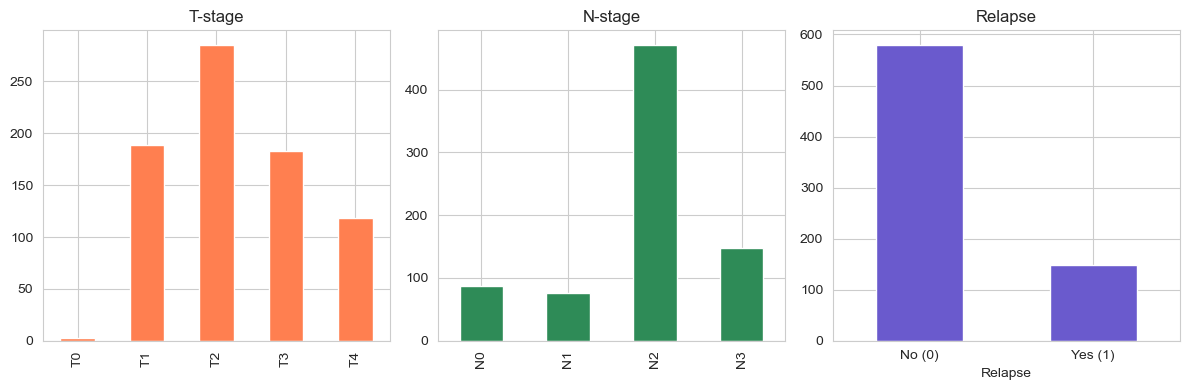

Relapse rate: 0.204
Median RFS (days): 1295.0


In [106]:
# Label distributions (Tasks 2 and 3)
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

rawDF["T-stage"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color="coral")
axes[0].set_title("T-stage")
axes[0].set_xlabel("")

rawDF["N-stage"].value_counts().sort_index().plot(kind="bar", ax=axes[1], color="seagreen")
axes[1].set_title("N-stage")
axes[1].set_xlabel("")

rawDF["Relapse"].value_counts().sort_index().plot(kind="bar", ax=axes[2], color="slateblue")
axes[2].set_title("Relapse")
axes[2].set_xticklabels(["No (0)", "Yes (1)"], rotation=0)

plt.tight_layout()
plt.show()

print("Relapse rate:", rawDF["Relapse"].mean().round(3))
print("Median RFS (days):", rawDF["RFS"].median())

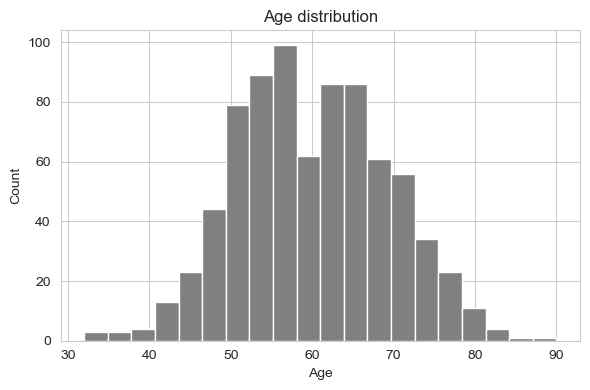

In [107]:
# Age distribution (only column with no missing values besides IDs)
plt.figure(figsize=(6, 4))
rawDF["Age"].hist(bins=20, color="gray", edgecolor="white")
plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Age distribution")
plt.tight_layout()
plt.show()

Alright, so:
- T-stage is fairly evenly distributed, but there are not that many T0 values to accurately represent them in the model
- N-stage is slightly left-skewed, with N2 dominating
- People do not tend to relapse
- Age is almost normal, maybe bimodal, when it comes to just the data count. Age range is 30-90.

### Correlation between target features and center

Just checking if our data has bias, maybe centers have a tendency to report one stage more than another

T-stage,T0,T1,T2,T3,T4
CenterID,,,,,
1.0,0.0,14.3,46.4,30.4,8.9
2.0,0.0,4.0,20.0,42.7,33.3
3.0,0.0,8.3,51.4,23.6,16.7
4.0,0.0,9.8,35.3,39.2,15.7
5.0,0.7,34.9,36.5,17.2,10.7
6.0,0.0,21.8,32.7,29.1,16.4
7.0,0.0,0.0,47.1,5.9,47.1
8.0,0.0,9.1,18.2,36.4,36.4


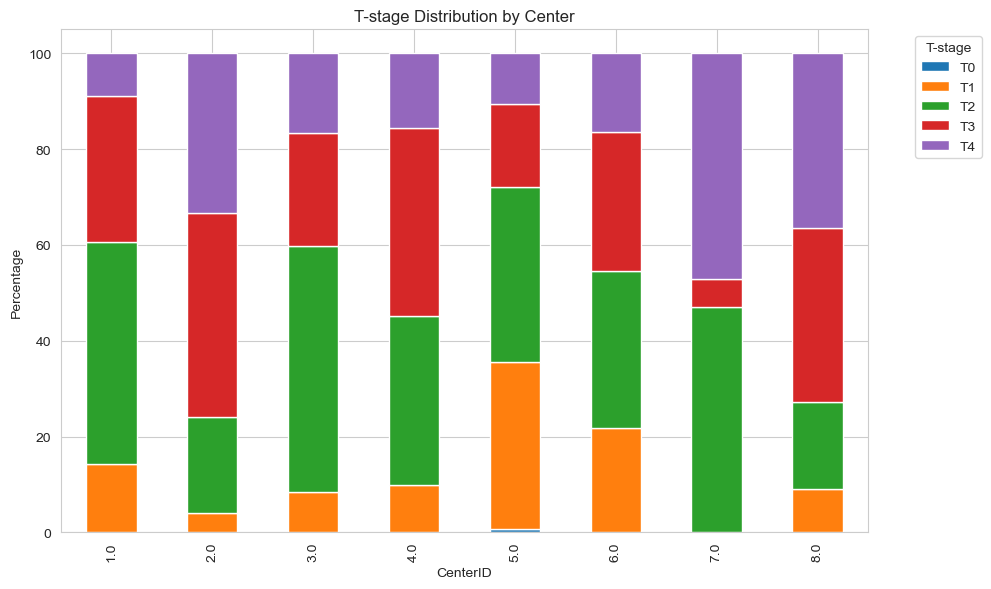

In [108]:
import pandas as pd
import matplotlib.pyplot as plt

# T-stage by center
t_center = pd.crosstab(rawDF["CenterID"], rawDF["T-stage"], normalize="index") * 100    # Make a table where it shows the proportion of each T-stage at each center
display(t_center.round(1))

t_center.plot(kind="bar", stacked=True, figsize=(10, 6))
plt.title("T-stage Distribution by Center")
plt.ylabel("Percentage")
plt.xlabel("CenterID")
plt.legend(title="T-stage", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

N-stage,N0,N1,N2,N3
CenterID,,,,
1.0,7.1,14.3,58.9,19.6
2.0,13.3,13.3,65.3,8.0
3.0,23.6,12.5,48.6,15.3
4.0,15.7,11.8,52.9,19.6
5.0,9.2,8.3,61.0,21.4
6.0,7.3,9.1,69.1,14.5
7.0,5.6,5.6,72.2,16.7
8.0,18.2,0.0,45.5,36.4


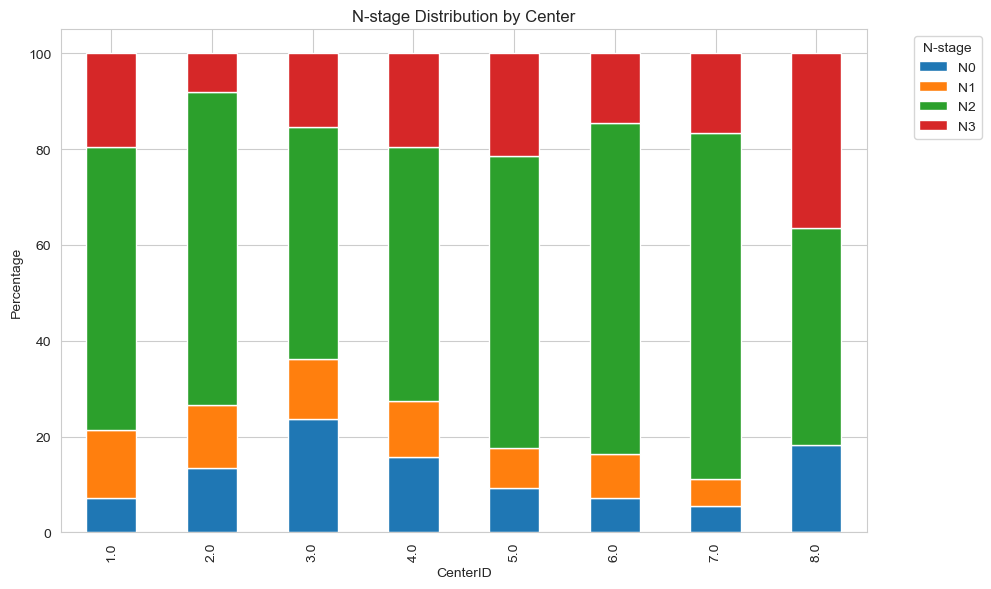

In [109]:
# N-stage by center
n_center = pd.crosstab(rawDF["CenterID"], rawDF["N-stage"], normalize="index") * 100
display(n_center.round(1))

n_center.plot(kind="bar", stacked=True, figsize=(10, 6))
plt.title("N-stage Distribution by Center")
plt.ylabel("Percentage")
plt.xlabel("CenterID")
plt.legend(title="N-stage", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

Relapse,0.0,1.0
CenterID,,
1.0,87.5,12.5
2.0,61.7,38.3
3.0,81.9,18.1
4.0,81.8,18.2
5.0,80.9,19.1
6.0,80.0,20.0
7.0,77.8,22.2
8.0,45.5,54.5


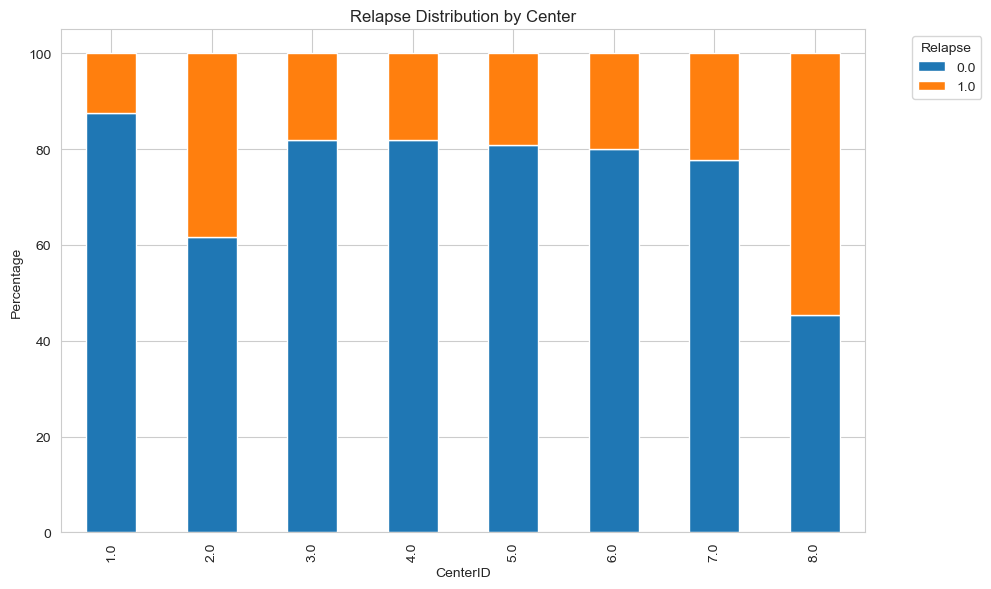

In [110]:
relapse_center = pd.crosstab(rawDF["CenterID"], rawDF["Relapse"], normalize="index") * 100
display(relapse_center.round(1))

relapse_center.plot(kind="bar", stacked=True, figsize=(10, 6))
plt.title("Relapse Distribution by Center")
plt.ylabel("Percentage")
plt.xlabel("CenterID")
plt.legend(title="Relapse", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

There seems to be some correlation, but I doubt it will affect the model all too much. (Center 8 has way more relapses, it also has no N1 stage).

### Checking whether there is any correlation between a missing value and the target features

I don't really know what else to check so lets see if the missing data actually tells us anything about the targets.

In [111]:
high_missing_cols = [
    "Performance Status",
    "Alcohol Consumption",
    "Tobacco Consumption",
    "HPV Status"
]

for col in high_missing_cols:
    rawDF[f"{col}_missing"] = rawDF[col].isna().astype(int)

rawDF[[f"{col}_missing" for col in high_missing_cols]].head()

,Performance Status_missing,Alcohol Consumption_missing,Tobacco Consumption_missing,HPV Status_missing
0,1,1,1,1
1,1,1,1,1
2,1,1,1,1
3,1,1,1,1
4,1,1,1,1


In [112]:
for col in high_missing_cols:
    miss_col = f"{col}_missing"
    
    print(f"\n{miss_col} vs T-stage")
    display(pd.crosstab(rawDF[miss_col], rawDF["T-stage"], normalize="index").round(3) * 100) 
    
    print(f"\n{miss_col} vs N-stage")
    display(pd.crosstab(rawDF[miss_col], rawDF["N-stage"], normalize="index").round(3) * 100)
    
    print(f"\n{miss_col} vs Relapse")
    display(pd.crosstab(rawDF[miss_col], rawDF["Relapse"], normalize="index").round(3) * 100)


Performance Status_missing vs T-stage


T-stage,T0,T1,T2,T3,T4
Performance Status_missing,,,,,
0,0.6,28.4,34.4,21.7,14.8
1,0.0,18.2,39.9,26.2,15.7



Performance Status_missing vs N-stage


N-stage,N0,N1,N2,N3
Performance Status_missing,,,,
0,9.8,8.5,62.0,19.7
1,13.1,11.5,57.6,17.8



Performance Status_missing vs Relapse


...

T-stage,T0,T1,T2,T3,T4
HPV Status_missing,,,,,
0,0.5,29.0,36.4,19.7,14.5
1,0.0,9.2,37.5,35.9,17.4



HPV Status_missing vs N-stage


N-stage,N0,N1,N2,N3
HPV Status_missing,,,,
0,10.1,8.5,62.3,19.1
1,14.6,13.5,53.5,18.4



HPV Status_missing vs Relapse


Relapse,0.0,1.0
HPV Status_missing,,
0,79.8,20.2
1,79.2,20.8


From these tables, it mostly seems like the N-stage and relapse fields remain unaffected. Its the T-stage (particularly T1) that may be concerning. Let's plot it out to see whether its worth considering all that much.


Performance Status missingness vs T-stage


T-stage,T0,T1,T2,T3,T4
Performance Status_missing,,,,,
0,0.6,28.4,34.4,21.7,14.8
1,0.0,18.2,39.9,26.2,15.7


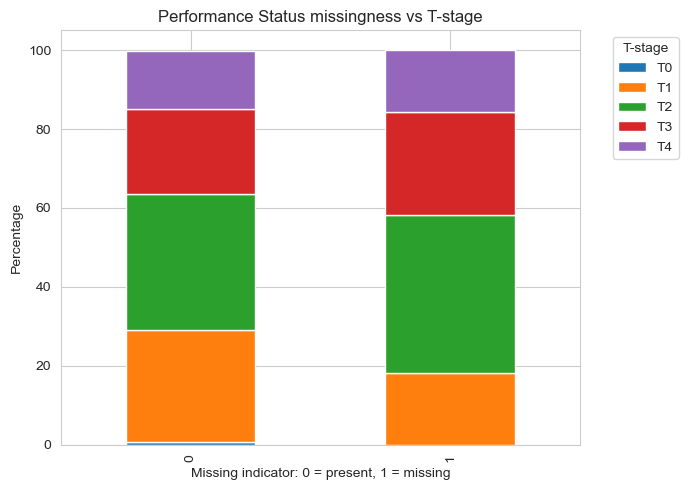


Alcohol Consumption missingness vs T-stage


T-stage,T0,T1,T2,T3,T4
Alcohol Consumption_missing,,,,,
0,0.6,30.8,33.9,20.7,14.0
1,0.0,11.7,41.9,29.1,17.4


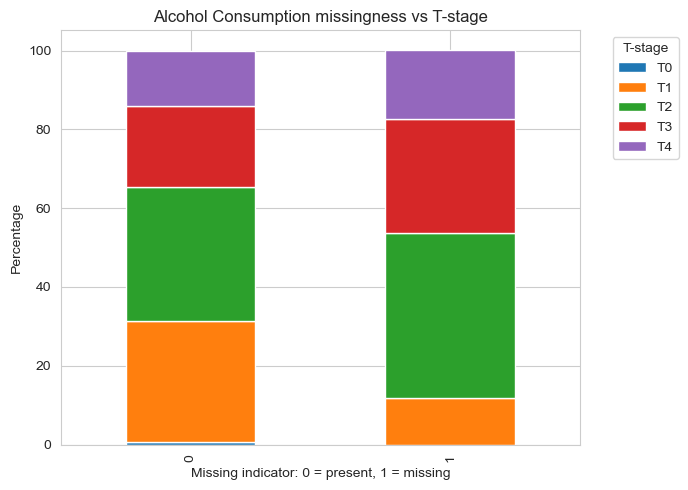


Tobacco Consumption missingness vs T-stage


T-stage,T0,T1,T2,T3,T4
Tobacco Consumption_missing,,,,,
0,0.6,30.4,33.9,21.0,14.1
1,0.0,12.0,42.1,28.6,17.4


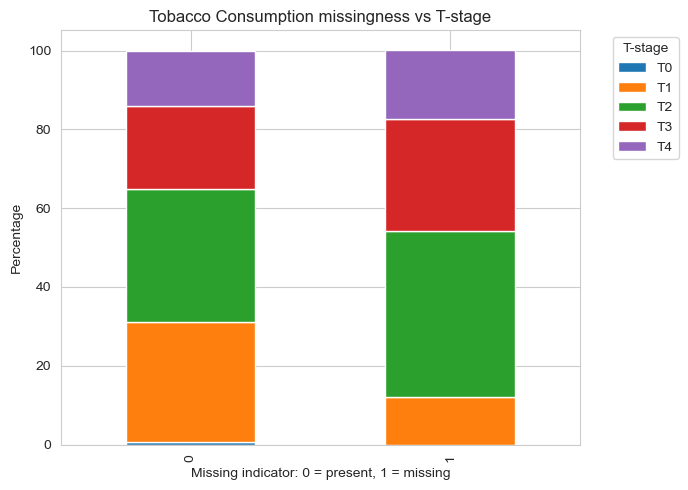


HPV Status missingness vs T-stage


T-stage,T0,T1,T2,T3,T4
HPV Status_missing,,,,,
0,0.5,29.0,36.4,19.7,14.5
1,0.0,9.2,37.5,35.9,17.4


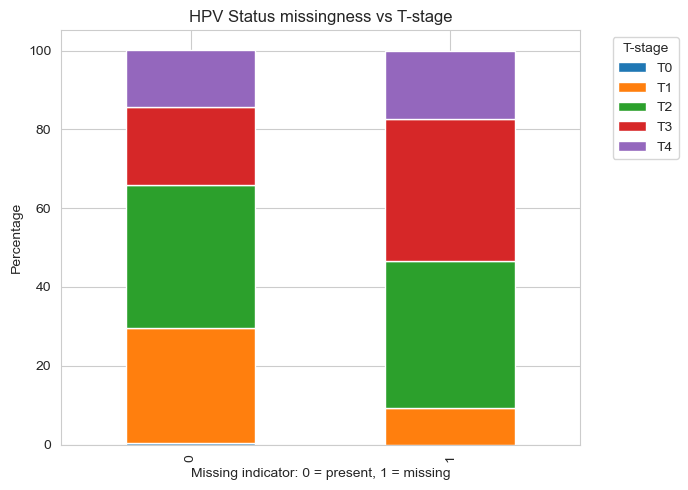

In [113]:
for col in high_missing_cols:
    miss_col = f"{col}_missing"

    print(f"\n{col} missingness vs T-stage")
    
    t_stage_table = (
        pd.crosstab(rawDF[miss_col], rawDF["T-stage"], normalize="index") * 100
    ).round(1)

    display(t_stage_table)

    t_stage_table.plot(
        kind="bar",
        stacked=True,
        figsize=(7, 5)
    )

    plt.title(f"{col} missingness vs T-stage")
    plt.xlabel("Missing indicator: 0 = present, 1 = missing")
    plt.ylabel("Percentage")
    plt.legend(title="T-stage", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

For T-stages, performance status does not seem to have much of an effect. However, for alcohol / tobacco consumption and HPV Status, there seems to be far less T1 stages and more T2/T3 stages. This might affect the model, especially the HPV status where there is a 20% decrease in T1 stage distribution.

### Some more correlations between columns and target features
Lets start with age.

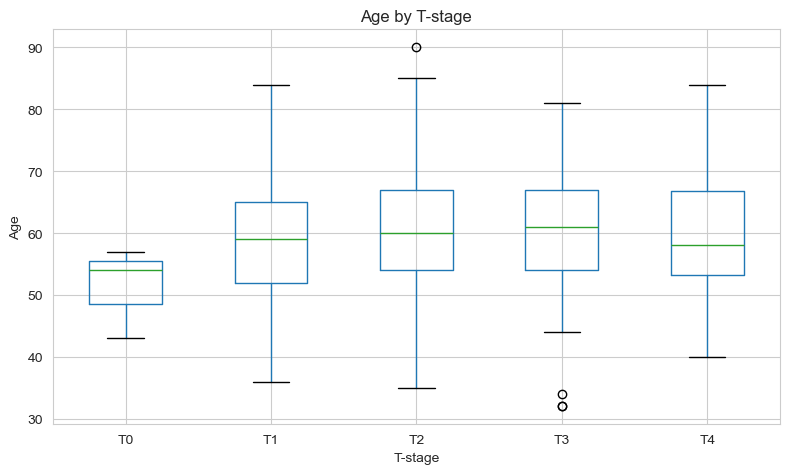

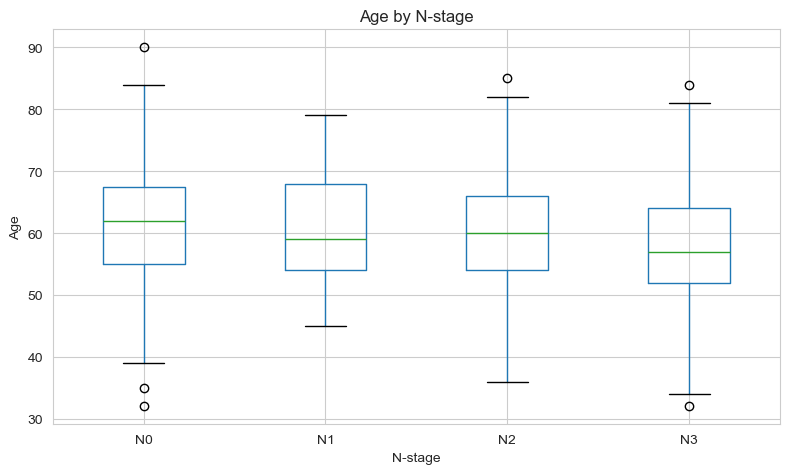

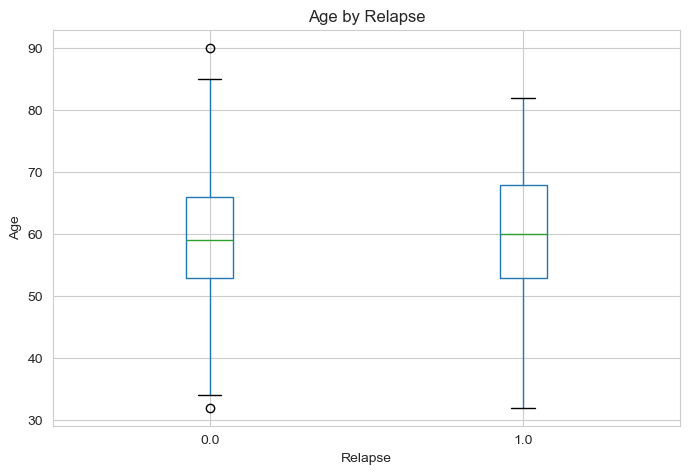

In [114]:
# Some basic Age correlatons:

rawDF.boxplot(column="Age", by="T-stage", figsize=(8, 5))
plt.title("Age by T-stage")
plt.suptitle("")
plt.xlabel("T-stage")
plt.ylabel("Age")
plt.tight_layout()
plt.show()

rawDF.boxplot(column="Age", by="N-stage", figsize=(8, 5))
plt.title("Age by N-stage")
plt.suptitle("")
plt.xlabel("N-stage")
plt.ylabel("Age")
plt.tight_layout()
plt.show()

rawDF.boxplot(column="Age", by="Relapse", figsize=(7, 5))
plt.title("Age by Relapse")
plt.suptitle("")
plt.xlabel("Relapse")
plt.ylabel("Age")
plt.tight_layout()
plt.show()

There doesn't seem to be a correlation here, pretty equal spread. The T0 spread is less because we have very few data points.

### Gender Correlation

Standard check.

T-stage,T0,T1,T2,T3,T4
Gender,,,,,
0.0,0.0,22.7,39.8,21.9,15.6
1.0,0.5,24.6,36.0,23.8,15.1


Text(0.5, 0, 'Gender')

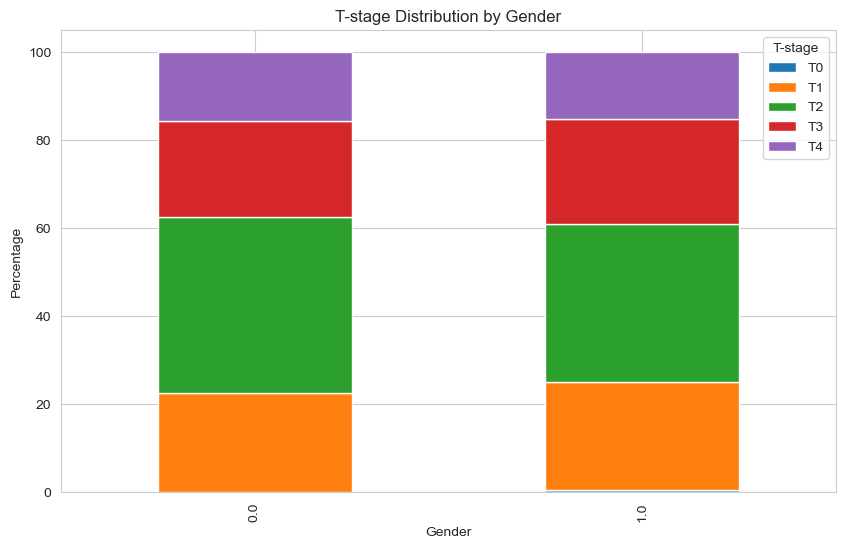

In [115]:
t_stage_gender = pd.crosstab(rawDF["Gender"], rawDF["T-stage"], normalize="index") * 100
display(t_stage_gender.round(1))

t_stage_gender.plot(kind="bar", stacked=True, figsize=(10, 6))
plt.title("T-stage Distribution by Gender")
plt.ylabel("Percentage")
plt.xlabel("Gender")

### Tobacco Consumption Correlation

## Data Cleaning For T-Stage Experiments

### Overview
Here is what I understood from the data, row-wise:
1. PatientID: Identifier, can be removed
2. CentreID: Might be useful for imputing missing features, does not seem to have a correlation with the actual target. Will keep one dataset with, and one dataset without
3. Age: Will keep, even though no apparent correlation was seen. Need to check for outliers and scaling since its 30-90
4. Gender: Categorical Binary, will keep
5. Tobacco: Categorical Binary, two sets: one where missing values are "Unknown" and one where they are imputed with mean (or scikit-learns method)
6. Alcohol: Same as tobacco
7. Performance Status: After research, this is ECOG status that might correlate more to Relapse than T-stage. Three experiments: "Unknown", impute, and removed
8. Treatment: Logically doesn't make sense to affecting the patients stage, so two experiments: one with, one without
9. HPV Status: "Unknown" plus impute. This feature had the highest missingess correlation with T-stage (20% less of T1 when missing)

Not using any target features for these experiments simply because they are not present in the test set. Later on, we can see if there is a need for them, then we can model the pipeline so that it predicts the other targets first and then feeds into this model.

### T-stage experiment overview

Goal: predict `T-stage` using clinical tabular features while checking how missing-value handling changes performance.

Setup:
- Usable rows: 778 patients with `T-stage` present.
- Split: stratified train / validation / test.
- Model: `RandomForestClassifier` baseline.
- Main metric: balanced accuracy, because T0 is extremely rare.
- Test set stays untouched during these comparisons.

Experiments:
- E0: Dummy most frequent baseline.
- E1: Age + Gender.
- E2: Age + Gender + CenterID.
- E3: Full clinical, missing values as `Unknown`.
- E4: Full clinical, global most-frequent imputation.
- E5: Full clinical without Performance Status.
- E6: Full clinical + Treatment, global most-frequent imputation.
- E7: Center-wise mode imputation.
- E8: Most-frequent imputation + missingness flags.

Important caveat: `Treatment` may be determined after staging, so E6-style results need to be interpreted cautiously.


In [116]:
from sklearn.model_selection import train_test_split

# 1. Focus on T-stage for now
df_t = rawDF.dropna(subset=["T-stage"]).copy()

# 2. Define target
y = df_t["T-stage"]

# 3. Drop columns we do not want as input features
drop_cols = [
    "PatientID",
    "T-stage",
    "N-stage",
    "Relapse",
    "RFS"
]

X = df_t.drop(columns=drop_cols)

# 4. First split: train+validation vs test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=42,
    stratify=y
)

# 5. Second split: train vs validation
# 0.1765 of 85% is approximately 15% of the original dataset
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.1765,
    random_state=42,
    stratify=y_train_val
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

print("\nTrain T-stage distribution:")
print(y_train.value_counts(normalize=True).sort_index().round(3))

print("\nValidation T-stage distribution:")
print(y_val.value_counts(normalize=True).sort_index().round(3))

print("\nTest T-stage distribution:")
print(y_test.value_counts(normalize=True).sort_index().round(3))

Train: (544, 12)
Validation: (117, 12)
Test: (117, 12)

Train T-stage distribution:
T-stage
T0    0.004
T1    0.244
T2    0.366
T3    0.235
T4    0.151
Name: proportion, dtype: float64

Validation T-stage distribution:
T-stage
T0    0.009
T1    0.239
T2    0.368
T3    0.231
T4    0.154
Name: proportion, dtype: float64

Test T-stage distribution:
T-stage
T1    0.239
T2    0.368
T3    0.239
T4    0.154
Name: proportion, dtype: float64


In [117]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import balanced_accuracy_score, accuracy_score, classification_report

dummy = DummyClassifier(strategy="most_frequent")

dummy.fit(X_train, y_train)
dummy_pred = dummy.predict(X_val)

dummy_bal_acc = balanced_accuracy_score(y_val, dummy_pred)
dummy_acc = accuracy_score(y_val, dummy_pred)

print("Dummy baseline:")
print("Most common class in train:", y_train.mode()[0])
print("Accuracy:", round(dummy_acc, 3))
print("Balanced accuracy:", round(dummy_bal_acc, 3))

print("\nClassification report:")
print(classification_report(y_val, dummy_pred, zero_division=0))

Dummy baseline:
Most common class in train: T2
Accuracy: 0.368
Balanced accuracy: 0.2

Classification report:
              precision    recall  f1-score   support

          T0       0.00      0.00      0.00         1
          T1       0.00      0.00      0.00        28
          T2       0.37      1.00      0.54        43
          T3       0.00      0.00      0.00        27
          T4       0.00      0.00      0.00        18

    accuracy                           0.37       117
   macro avg       0.07      0.20      0.11       117
weighted avg       0.14      0.37      0.20       117



In [118]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

def make_rf_pipeline(
    numeric_features,
    categorical_features,
    categorical_strategy="unknown"
):
    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ])

    if categorical_strategy == "unknown":
        categorical_transformer = Pipeline(steps=[
            # Step 1: allow string values like "Unknown"
            ("to_object", FunctionTransformer(lambda x: x.astype(object), validate=False)),
            
            # Step 2: fill missing values with "Unknown"
            ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
            
            # Step 3: make all categories strings: 0.0 -> "0.0", 1.0 -> "1.0", Unknown -> "Unknown"
            ("to_string", FunctionTransformer(lambda x: x.astype(str), validate=False)),
            
            # Step 4: one-hot encode
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ])

    elif categorical_strategy == "most_frequent":
        categorical_transformer = Pipeline(steps=[
            ("to_object", FunctionTransformer(lambda x: x.astype(object), validate=False)),
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("to_string", FunctionTransformer(lambda x: x.astype(str), validate=False)),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ])

    else:
        raise ValueError("categorical_strategy must be 'unknown' or 'most_frequent'")

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat", categorical_transformer, categorical_features)
        ],
        remainder="drop"
    )

    model = RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced"
    )

    return Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", model)
    ])

In [119]:
# The run method

experiment_results = {}

def run_experiment(
    name,
    numeric_features,
    categorical_features,
    categorical_strategy="unknown"
):
    pipe = make_rf_pipeline(
        numeric_features=numeric_features,
        categorical_features=categorical_features,
        categorical_strategy=categorical_strategy
    )

    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_val)

    bal_acc = balanced_accuracy_score(y_val, preds)
    acc = accuracy_score(y_val, preds)

    experiment_results[name] = {
        "pipeline": pipe,
        "balanced_accuracy": bal_acc,
        "accuracy": acc,
        "numeric_features": numeric_features,
        "categorical_features": categorical_features,
        "categorical_strategy": categorical_strategy
    }

    print("=" * 80)
    print(name)
    print("Balanced accuracy:", round(bal_acc, 3))
    print("Accuracy:", round(acc, 3))

    print("\nClassification report:")
    print(classification_report(y_val, preds, zero_division=0))

    return pipe


In [120]:
experiment_results = {}

run_experiment(
    name="E1: Age + Gender",
    numeric_features=["Age"],
    categorical_features=["Gender"],
    categorical_strategy="unknown"
)

run_experiment(
    name="E2: Age + Gender + CenterID",
    numeric_features=["Age"],
    categorical_features=["Gender", "CenterID"],
    categorical_strategy="unknown"
)

run_experiment(
    name="E3: Full clinical, missing = Unknown",
    numeric_features=["Age"],
    categorical_features=[
        "Gender",
        "CenterID",
        "Tobacco Consumption",
        "Alcohol Consumption",
        "Performance Status",
        "HPV Status"
    ],
    categorical_strategy="unknown"
)

run_experiment(
    name="E4: Full clinical, most_frequent imputation",
    numeric_features=["Age"],
    categorical_features=[
        "Gender",
        "CenterID",
        "Tobacco Consumption",
        "Alcohol Consumption",
        "Performance Status",
        "HPV Status"
    ],
    categorical_strategy="most_frequent"
)

run_experiment(
    name="E5: Full clinical without Performance Status, missing = Unknown",
    numeric_features=["Age"],
    categorical_features=[
        "Gender",
        "CenterID",
        "Tobacco Consumption",
        "Alcohol Consumption",
        "HPV Status"
    ],
    categorical_strategy="unknown"
)

run_experiment(
    name="E6: Full clinical + Treatment, missing = Unknown",
    numeric_features=["Age"],
    categorical_features=[
        "Gender",
        "CenterID",
        "Tobacco Consumption",
        "Alcohol Consumption",
        "Performance Status",
        "HPV Status",
        "Treatment"
    ],
    categorical_strategy="most_frequent"
)

E1: Age + Gender
Balanced accuracy: 0.2
Accuracy: 0.231

Classification report:
              precision    recall  f1-score   support

          T0       0.00      0.00      0.00         1
          T1       0.23      0.36      0.28        28
          T2       0.39      0.16      0.23        43
          T3       0.18      0.15      0.16        27
          T4       0.25      0.33      0.29        18

    accuracy                           0.23       117
   macro avg       0.21      0.20      0.19       117
weighted avg       0.28      0.23      0.23       117

E2: Age + Gender + CenterID
Balanced accuracy: 0.227
Accuracy: 0.291

Classification report:
              precision    recall  f1-score   support

          T0       0.00      0.00      0.00         1
          T1       0.36      0.50      0.42        28
          T2       0.42      0.30      0.35        43
          T3       0.18      0.11      0.14        27
          T4       0.17      0.22      0.20        18

    accuracy

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Age']),
                                                 ('cat',
                                                  Pipeline(steps=[('to_object',
                                                                   FunctionTransformer(func=<function make_rf_pipeline.<locals>.<lambda> at 0x3560cc7c0>)),
                                                                  ('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('to_string',
                                                                   FunctionTransformer(func=<function make_rf_pipeline.<locals>.<lambda> at 0x36abed260>)),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender', 'CenterID',
                                                   'Tobacco Consumption',
                                                   'Alcohol Consumption',
                                                   'Performance Status',
                                                   'HPV Status',
                                                   'Treatment'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=300, random_state=42))])

Alright, so it would seem experiment 6 performed the best, as expected. Now, lets try and find a better way to impute the values for the missing features based on centre ID, since there was a big correlation we saw before.

In [121]:
def get_most_common_value(series):
    """
    Returns the most common non-missing value in a column.
    """
    counts = series.value_counts(dropna=True)

    if len(counts) == 0:
        return None

    return counts.index[0]


def learn_center_modes(train_df, center_col, cols_to_impute):
    """
    Learns:
    1. global most common value for each column
    2. most common value per center for each column

    Uses training data only.
    """

    global_modes = {}
    center_modes = {}

    for col in cols_to_impute:
        # Most common value in the whole training set
        global_modes[col] = get_most_common_value(train_df[col])

        center_modes[col] = {}

        # Go center by center
        unique_centers = train_df[center_col].dropna().unique()

        for center in unique_centers:
            center_rows = train_df[train_df[center_col] == center]

            center_mode = get_most_common_value(center_rows[col])

            # If this center has no available values for this column, use the global most common value instead
            if center_mode is None:
                center_mode = global_modes[col]

            center_modes[col][center] = center_mode

    return global_modes, center_modes

In [122]:
def apply_center_modes(df, center_col, cols_to_impute, global_modes, center_modes):
    """
    Fills missing values using:
    1. center-specific mode if available
    2. global mode if center-specific mode is not available
    """

    df_filled = df.copy()

    for col in cols_to_impute:
        for row_index in df_filled.index:
            value = df_filled.loc[row_index, col]

            # Only fill missing values
            if pd.isna(value):
                center = df_filled.loc[row_index, center_col]

                # Try to get this center's mode
                if center in center_modes[col]:
                    fill_value = center_modes[col][center]
                else:
                    fill_value = global_modes[col]

                df_filled.loc[row_index, col] = fill_value

    return df_filled

In [123]:
cols_to_center_impute = [
    "Tobacco Consumption",
    "Alcohol Consumption",
    "Performance Status",
    "HPV Status",
    "Treatment"
]

global_modes, center_modes = learn_center_modes(
    train_df=X_train,
    center_col="CenterID",
    cols_to_impute=cols_to_center_impute
)

X_train_center = apply_center_modes(
    df=X_train,
    center_col="CenterID",
    cols_to_impute=cols_to_center_impute,
    global_modes=global_modes,
    center_modes=center_modes
)

X_val_center = apply_center_modes(
    df=X_val,
    center_col="CenterID",
    cols_to_impute=cols_to_center_impute,
    global_modes=global_modes,
    center_modes=center_modes
)

X_test_center = apply_center_modes(
    df=X_test,
    center_col="CenterID",
    cols_to_impute=cols_to_center_impute,
    global_modes=global_modes,
    center_modes=center_modes
)

In [124]:
# Little sanity check before we move on:
print(X_train_center[cols_to_center_impute].isna().sum())
print(X_val_center[cols_to_center_impute].isna().sum())
print(X_test_center[cols_to_center_impute].isna().sum())

Tobacco Consumption    0
Alcohol Consumption    0
Performance Status     0
HPV Status             0
Treatment              0
dtype: int64
Tobacco Consumption    0
Alcohol Consumption    0
Performance Status     0
HPV Status             0
Treatment              0
dtype: int64
Tobacco Consumption    0
Alcohol Consumption    0
Performance Status     0
HPV Status             0
Treatment              0
dtype: int64


In [125]:
from sklearn.metrics import balanced_accuracy_score, accuracy_score, classification_report, confusion_matrix

e7_numeric = ["Age"]

e7_categorical = [
    "Gender",
    "CenterID",
    "Tobacco Consumption",
    "Alcohol Consumption",
    "Performance Status",
    "HPV Status",
    "Treatment"
]

e7_pipe = make_rf_pipeline(
    numeric_features=e7_numeric,
    categorical_features=e7_categorical,
    categorical_strategy="most_frequent"
)

e7_pipe.fit(X_train_center, y_train)
e7_preds = e7_pipe.predict(X_val_center)

e7_bal_acc = balanced_accuracy_score(y_val, e7_preds)
e7_acc = accuracy_score(y_val, e7_preds)

print("E7: Full clinical + Treatment, center-wise mode imputation")
print("Balanced accuracy:", round(e7_bal_acc, 3))
print("Accuracy:", round(e7_acc, 3))

print("\nClassification report:")
print(classification_report(y_val, e7_preds, zero_division=0))

print("\nConfusion matrix:")
print(confusion_matrix(y_val, e7_preds))

E7: Full clinical + Treatment, center-wise mode imputation
Balanced accuracy: 0.316
Accuracy: 0.385

Classification report:
              precision    recall  f1-score   support

          T0       0.00      0.00      0.00         1
          T1       0.50      0.61      0.55        28
          T2       0.47      0.33      0.38        43
          T3       0.24      0.26      0.25        27
          T4       0.30      0.39      0.34        18

    accuracy                           0.38       117
   macro avg       0.30      0.32      0.30       117
weighted avg       0.39      0.38      0.38       117


Confusion matrix:
[[ 0  0  0  0  1]
 [ 0 17  6  2  3]
 [ 1 11 14 14  3]
 [ 0  5  6  7  9]
 [ 0  1  4  6  7]]


Ok, this experiment seemed to have run worse than the E6. I will try one last experiment where I use the most frequent imputation and a separate column for missingness indicator, since I really want to see if the missingness correlation I found actually affects anything.

In [126]:
def add_missing_flags(X, cols_to_flag):
    X_copy = X.copy()

    for col in cols_to_flag:
        flag_col_name = col + "_missing"
        X_copy[flag_col_name] = X_copy[col].isna().astype(int)

    return X_copy

cols_to_flag = [
    "Tobacco Consumption",
    "Alcohol Consumption",
    "Performance Status",
    "HPV Status",
    "Treatment"
]

X_train_e8 = add_missing_flags(X_train, cols_to_flag)
X_val_e8 = add_missing_flags(X_val, cols_to_flag)
X_test_e8 = add_missing_flags(X_test, cols_to_flag)

e8_numeric = [
    "Age",
    "Tobacco Consumption_missing",
    "Alcohol Consumption_missing",
    "Performance Status_missing",
    "HPV Status_missing",
    "Treatment_missing"
]

e8_categorical = [
    "Gender",
    "CenterID",
    "Tobacco Consumption",
    "Alcohol Consumption",
    "Performance Status",
    "HPV Status",
    "Treatment"
]

In [127]:
from sklearn.metrics import balanced_accuracy_score, accuracy_score, classification_report, confusion_matrix

e8_pipe = make_rf_pipeline(
    numeric_features=e8_numeric,
    categorical_features=e8_categorical,
    categorical_strategy="most_frequent"
)

e8_pipe.fit(X_train_e8, y_train)
e8_preds = e8_pipe.predict(X_val_e8)

e8_bal_acc = balanced_accuracy_score(y_val, e8_preds)
e8_acc = accuracy_score(y_val, e8_preds)

print("E8: Full clinical + Treatment, most_frequent imputation + missing flags")
print("Balanced accuracy:", round(e8_bal_acc, 3))
print("Accuracy:", round(e8_acc, 3))

print("\nClassification report:")
print(classification_report(y_val, e8_preds, zero_division=0))

print("\nConfusion matrix:")
print(confusion_matrix(y_val, e8_preds))

E8: Full clinical + Treatment, most_frequent imputation + missing flags
Balanced accuracy: 0.315
Accuracy: 0.376

Classification report:
              precision    recall  f1-score   support

          T0       0.00      0.00      0.00         1
          T1       0.46      0.57      0.51        28
          T2       0.41      0.30      0.35        43
          T3       0.25      0.26      0.25        27
          T4       0.38      0.44      0.41        18

    accuracy                           0.38       117
   macro avg       0.30      0.32      0.30       117
weighted avg       0.38      0.38      0.37       117


Confusion matrix:
[[ 0  0  0  1  0]
 [ 0 16  8  3  1]
 [ 1 12 13 13  4]
 [ 0  6  6  7  8]
 [ 0  1  5  4  8]]


Alright, then that's that. E6 is the best dataset performance. This is the highest performing setup, but because Treatment may be determined after staging, results using Treatment should be interpreted cautiously.

## Data Cleaning For N-Stage Experiments


### N-stage experiment overview

Goal: predict `N-stage` with the same general preprocessing style that worked best for T-stage.

Setup:
- Usable rows: all 782 patients, because `N-stage` has no missing labels.
- Split: stratified train / validation / test by `N-stage`.
- Model: `RandomForestClassifier` baseline.
- Main metric: balanced accuracy, because N2 dominates the label distribution.
- Test set stays untouched during these comparisons.

Experiments:
- N0: Dummy most frequent baseline.
- N1: Age + Gender.
- N2: Age + Gender + CenterID.
- N3: Full clinical without Treatment, global most-frequent imputation.
- N4: Full clinical + Treatment, global most-frequent imputation.


In [128]:
# 1. Focus on N-stage
# N-stage has no missing labels, so this should keep all patients.
df_n = rawDF.dropna(subset=["N-stage"]).copy()

# 2. Define target
y_n = df_n["N-stage"]

# 3. Drop columns we do not want as input features
n_drop_cols = [
    "PatientID",
    "N-stage",
    "T-stage",
    "Relapse",
    "RFS"
]

X_n = df_n.drop(columns=n_drop_cols)

# 4. First split: train+validation vs test
X_n_train_val, X_n_test, y_n_train_val, y_n_test = train_test_split(
    X_n,
    y_n,
    test_size=0.15,
    random_state=42,
    stratify=y_n
)

# 5. Second split: train vs validation
# 0.1765 of 85% is approximately 15% of the original dataset
X_n_train, X_n_val, y_n_train, y_n_val = train_test_split(
    X_n_train_val,
    y_n_train_val,
    test_size=0.1765,
    random_state=42,
    stratify=y_n_train_val
)

print("N-stage usable rows:", len(df_n))
print("Train:", X_n_train.shape)
print("Validation:", X_n_val.shape)
print("Test:", X_n_test.shape)

print("\nTrain N-stage distribution:")
print(y_n_train.value_counts(normalize=True).sort_index().round(3))

print("\nValidation N-stage distribution:")
print(y_n_val.value_counts(normalize=True).sort_index().round(3))

print("\nTest N-stage distribution:")
print(y_n_test.value_counts(normalize=True).sort_index().round(3))


N-stage usable rows: 782
Train: (546, 12)
Validation: (118, 12)
Test: (118, 12)

Train N-stage distribution:
N-stage
N0    0.112
N1    0.097
N2    0.603
N3    0.189
Name: proportion, dtype: float64

Validation N-stage distribution:
N-stage
N0    0.110
N1    0.093
N2    0.602
N3    0.195
Name: proportion, dtype: float64

Test N-stage distribution:
N-stage
N0    0.110
N1    0.102
N2    0.602
N3    0.186
Name: proportion, dtype: float64


In [129]:
n_dummy = DummyClassifier(strategy="most_frequent")

n_dummy.fit(X_n_train, y_n_train)
n_dummy_pred = n_dummy.predict(X_n_val)

n_dummy_bal_acc = balanced_accuracy_score(y_n_val, n_dummy_pred)
n_dummy_acc = accuracy_score(y_n_val, n_dummy_pred)

print("N0: Dummy most frequent")
print("Most common class in train:", y_n_train.mode()[0])
print("Accuracy:", round(n_dummy_acc, 3))
print("Balanced accuracy:", round(n_dummy_bal_acc, 3))

print("\nClassification report:")
print(classification_report(y_n_val, n_dummy_pred, zero_division=0))


N0: Dummy most frequent
Most common class in train: N2
Accuracy: 0.602
Balanced accuracy: 0.25

Classification report:
              precision    recall  f1-score   support

          N0       0.00      0.00      0.00        13
          N1       0.00      0.00      0.00        11
          N2       0.60      1.00      0.75        71
          N3       0.00      0.00      0.00        23

    accuracy                           0.60       118
   macro avg       0.15      0.25      0.19       118
weighted avg       0.36      0.60      0.45       118



In [130]:
n_stage_results = {}

def run_n_stage_experiment(
    name,
    numeric_features,
    categorical_features,
    categorical_strategy="most_frequent"
):
    pipe = make_rf_pipeline(
        numeric_features=numeric_features,
        categorical_features=categorical_features,
        categorical_strategy=categorical_strategy
    )

    pipe.fit(X_n_train, y_n_train)
    preds = pipe.predict(X_n_val)

    bal_acc = balanced_accuracy_score(y_n_val, preds)
    acc = accuracy_score(y_n_val, preds)

    n_stage_results[name] = {
        "pipeline": pipe,
        "balanced_accuracy": bal_acc,
        "accuracy": acc,
        "numeric_features": numeric_features,
        "categorical_features": categorical_features,
        "categorical_strategy": categorical_strategy
    }

    print("=" * 80)
    print(name)
    print("Balanced accuracy:", round(bal_acc, 3))
    print("Accuracy:", round(acc, 3))

    print("\nClassification report:")
    print(classification_report(y_n_val, preds, zero_division=0))

    return pipe


In [131]:
n_stage_results = {}

run_n_stage_experiment(
    name="N1: Age + Gender",
    numeric_features=["Age"],
    categorical_features=["Gender"],
    categorical_strategy="most_frequent"
)

run_n_stage_experiment(
    name="N2: Age + Gender + CenterID",
    numeric_features=["Age"],
    categorical_features=["Gender", "CenterID"],
    categorical_strategy="most_frequent"
)

run_n_stage_experiment(
    name="N3: Full clinical, no Treatment, most_frequent imputation",
    numeric_features=["Age"],
    categorical_features=[
        "Gender",
        "CenterID",
        "Tobacco Consumption",
        "Alcohol Consumption",
        "Performance Status",
        "HPV Status"
    ],
    categorical_strategy="most_frequent"
)

run_n_stage_experiment(
    name="N4: Full clinical + Treatment, most_frequent imputation",
    numeric_features=["Age"],
    categorical_features=[
        "Gender",
        "CenterID",
        "Tobacco Consumption",
        "Alcohol Consumption",
        "Performance Status",
        "HPV Status",
        "Treatment"
    ],
    categorical_strategy="most_frequent"
)


N1: Age + Gender
Balanced accuracy: 0.251
Accuracy: 0.331

Classification report:
              precision    recall  f1-score   support

          N0       0.14      0.15      0.15        13
          N1       0.07      0.18      0.11        11
          N2       0.62      0.41      0.49        71
          N3       0.20      0.26      0.23        23

    accuracy                           0.33       118
   macro avg       0.26      0.25      0.24       118
weighted avg       0.43      0.33      0.37       118

N2: Age + Gender + CenterID
Balanced accuracy: 0.316
Accuracy: 0.39

Classification report:
              precision    recall  f1-score   support

          N0       0.29      0.38      0.33        13
          N1       0.17      0.18      0.17        11
          N2       0.59      0.48      0.53        71
          N3       0.16      0.22      0.19        23

    accuracy                           0.39       118
   macro avg       0.30      0.32      0.30       118
weighted av

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Age']),
                                                 ('cat',
                                                  Pipeline(steps=[('to_object',
                                                                   FunctionTransformer(func=<function make_rf_pipeline.<locals>.<lambda> at 0x3625634c0>)),
                                                                  ('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('to_string',
                                                                   FunctionTransformer(func=<function make_rf_pipeline.<locals>.<lambda> at 0x3560cce00>)),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender', 'CenterID',
                                                   'Tobacco Consumption',
                                                   'Alcohol Consumption',
                                                   'Performance Status',
                                                   'HPV Status',
                                                   'Treatment'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=300, random_state=42))])

## Data Cleaning For RFS / Prognosis Experiments

For prognosis, I can frame the task in three different ways:
1. Relapse classification: predict whether relapse happened.
2. RFS regression: predict the recurrence-free survival time directly.
3. Survival analysis: use RFS as the time variable and Relapse as the event indicator.

For now, I am only adding simple baselines for relapse classification and RFS regression. Survival analysis will need a separate setup later.


In [132]:
# Use only rows with both prognosis labels present.
df_rfs = rawDF.dropna(subset=["Relapse", "RFS"]).copy()

# Relapse and RFS are both targets for different prognosis framings.
y_relapse = df_rfs["Relapse"]
y_rfs = df_rfs["RFS"]

# Relapse is not included in the feature matrix, because it would leak into RFS regression.
prog_drop_cols = [
    "PatientID",
    "Relapse",
    "RFS"
]

X_prog = df_rfs.drop(columns=prog_drop_cols)

# Shared split for relapse classification and RFS regression.
# Stratify by Relapse so the relapse rate stays similar across splits.
X_prog_train_val, X_prog_test, y_relapse_train_val, y_relapse_test, y_rfs_train_val, y_rfs_test = train_test_split(
    X_prog,
    y_relapse,
    y_rfs,
    test_size=0.15,
    random_state=42,
    stratify=y_relapse
)

X_prog_train, X_prog_val, y_relapse_train, y_relapse_val, y_rfs_train, y_rfs_val = train_test_split(
    X_prog_train_val,
    y_relapse_train_val,
    y_rfs_train_val,
    test_size=0.1765,
    random_state=42,
    stratify=y_relapse_train_val
)

print("Prognosis usable rows:", len(df_rfs))
print("Train:", X_prog_train.shape)
print("Validation:", X_prog_val.shape)
print("Test:", X_prog_test.shape)

print("\nTrain Relapse distribution:")
print(y_relapse_train.value_counts(normalize=True).sort_index().round(3))

print("\nValidation Relapse distribution:")
print(y_relapse_val.value_counts(normalize=True).sort_index().round(3))

print("\nTest Relapse distribution:")
print(y_relapse_test.value_counts(normalize=True).sort_index().round(3))

print("\nRelapse in RFS regression features:", "Relapse" in X_prog.columns)


Prognosis usable rows: 727
Train: (508, 14)
Validation: (109, 14)
Test: (110, 14)

Train Relapse distribution:
Relapse
0.0    0.795
1.0    0.205
Name: proportion, dtype: float64

Validation Relapse distribution:
Relapse
0.0    0.798
1.0    0.202
Name: proportion, dtype: float64

Test Relapse distribution:
Relapse
0.0    0.8
1.0    0.2
Name: proportion, dtype: float64

Relapse in RFS regression features: False


### Relapse classification experiment overview

Goal: predict whether a patient relapsed using rows where both `Relapse` and `RFS` are present.

Setup:
- Usable rows: 727 patients with both prognosis labels present.
- Split: shared stratified train / validation / test by `Relapse`.
- Model: `RandomForestClassifier` baseline.
- Main metric: balanced accuracy, because relapse is the minority class.
- Secondary metric: C-index, using predicted relapse probability as the risk score.
- Test set stays untouched during these comparisons.

Experiments:
- R-C0: Dummy most frequent baseline.
- R-C1: Clinical only, no T-stage/N-stage.
- R-C2: Clinical + T-stage + N-stage.

Caveat: T-stage and N-stage are clinically meaningful predictors only if they are available at prediction time.


In [133]:
def calculate_c_index(times, events, risk_scores):
    times = np.asarray(times, dtype=float)
    events = np.asarray(events, dtype=int)
    risk_scores = np.asarray(risk_scores, dtype=float)

    concordant = 0
    tied_risk = 0
    comparable = 0

    for i in range(len(times)):
        for j in range(i + 1, len(times)):
            if times[i] == times[j]:
                continue

            if times[i] < times[j] and events[i] == 1:
                comparable += 1

                if risk_scores[i] > risk_scores[j]:
                    concordant += 1
                elif risk_scores[i] == risk_scores[j]:
                    tied_risk += 1

            elif times[j] < times[i] and events[j] == 1:
                comparable += 1

                if risk_scores[j] > risk_scores[i]:
                    concordant += 1
                elif risk_scores[j] == risk_scores[i]:
                    tied_risk += 1

    if comparable == 0:
        return np.nan

    return (concordant + 0.5 * tied_risk) / comparable


def get_relapse_risk_scores(model, X):
    classes = list(model.classes_)
    relapse_class_index = classes.index(1.0)

    return model.predict_proba(X)[:, relapse_class_index]


relapse_dummy = DummyClassifier(strategy="most_frequent")

relapse_dummy.fit(X_prog_train, y_relapse_train)
relapse_dummy_pred = relapse_dummy.predict(X_prog_val)
relapse_dummy_risk = get_relapse_risk_scores(relapse_dummy, X_prog_val)

relapse_dummy_bal_acc = balanced_accuracy_score(y_relapse_val, relapse_dummy_pred)
relapse_dummy_acc = accuracy_score(y_relapse_val, relapse_dummy_pred)
relapse_dummy_c_index = calculate_c_index(y_rfs_val, y_relapse_val, relapse_dummy_risk)

print("R-C0: Dummy most frequent")
print("Most common class in train:", y_relapse_train.mode()[0])
print("Accuracy:", round(relapse_dummy_acc, 3))
print("Balanced accuracy:", round(relapse_dummy_bal_acc, 3))
print("C-index:", round(relapse_dummy_c_index, 3))

print("\nClassification report:")
print(classification_report(y_relapse_val, relapse_dummy_pred, zero_division=0))


R-C0: Dummy most frequent
Most common class in train: 0.0
Accuracy: 0.798
Balanced accuracy: 0.5
C-index: 0.5

Classification report:
              precision    recall  f1-score   support

         0.0       0.80      1.00      0.89        87
         1.0       0.00      0.00      0.00        22

    accuracy                           0.80       109
   macro avg       0.40      0.50      0.44       109
weighted avg       0.64      0.80      0.71       109



In [134]:
relapse_classification_results = {}

def run_relapse_classification_experiment(
    name,
    numeric_features,
    categorical_features,
    categorical_strategy="most_frequent"
):
    pipe = make_rf_pipeline(
        numeric_features=numeric_features,
        categorical_features=categorical_features,
        categorical_strategy=categorical_strategy
    )

    pipe.fit(X_prog_train, y_relapse_train)
    preds = pipe.predict(X_prog_val)
    risk_scores = get_relapse_risk_scores(pipe, X_prog_val)

    bal_acc = balanced_accuracy_score(y_relapse_val, preds)
    acc = accuracy_score(y_relapse_val, preds)
    c_index = calculate_c_index(y_rfs_val, y_relapse_val, risk_scores)

    relapse_classification_results[name] = {
        "pipeline": pipe,
        "balanced_accuracy": bal_acc,
        "accuracy": acc,
        "c_index": c_index,
        "numeric_features": numeric_features,
        "categorical_features": categorical_features,
        "categorical_strategy": categorical_strategy
    }

    print("=" * 80)
    print(name)
    print("Balanced accuracy:", round(bal_acc, 3))
    print("Accuracy:", round(acc, 3))
    print("C-index:", round(c_index, 3))

    print("\nClassification report:")
    print(classification_report(y_relapse_val, preds, zero_division=0))

    return pipe


In [135]:
prog_clinical_numeric = ["Age"]

prog_clinical_categorical = [
    "Gender",
    "CenterID",
    "Tobacco Consumption",
    "Alcohol Consumption",
    "Performance Status",
    "HPV Status",
    "Treatment"
]

prog_clinical_staging_categorical = [
    "Gender",
    "CenterID",
    "Tobacco Consumption",
    "Alcohol Consumption",
    "Performance Status",
    "HPV Status",
    "Treatment",
    "T-stage",
    "N-stage"
]

relapse_classification_results = {}

run_relapse_classification_experiment(
    name="R-C1: Clinical only, no T-stage/N-stage",
    numeric_features=prog_clinical_numeric,
    categorical_features=prog_clinical_categorical,
    categorical_strategy="most_frequent"
)

run_relapse_classification_experiment(
    name="R-C2: Clinical + T-stage + N-stage",
    numeric_features=prog_clinical_numeric,
    categorical_features=prog_clinical_staging_categorical,
    categorical_strategy="most_frequent"
)


R-C1: Clinical only, no T-stage/N-stage
Balanced accuracy: 0.408
Accuracy: 0.624
C-index: 0.458

Classification report:
              precision    recall  f1-score   support

         0.0       0.76      0.77      0.77        87
         1.0       0.05      0.05      0.05        22

    accuracy                           0.62       109
   macro avg       0.40      0.41      0.41       109
weighted avg       0.62      0.62      0.62       109

R-C2: Clinical + T-stage + N-stage
Balanced accuracy: 0.482
Accuracy: 0.716
C-index: 0.532

Classification report:
              precision    recall  f1-score   support

         0.0       0.79      0.87      0.83        87
         1.0       0.15      0.09      0.11        22

    accuracy                           0.72       109
   macro avg       0.47      0.48      0.47       109
weighted avg       0.66      0.72      0.69       109



Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Age']),
                                                 ('cat',
                                                  Pipeline(steps=[('to_object',
                                                                   FunctionTransformer(func=<function make_rf_pipeline.<locals>.<lambda> at 0x36aba5260>)),
                                                                  ('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('to_string',
                                                                   FunctionTransformer(func=<function make_rf_pipeline.<locals>.<lambda> at 0x3560cca40>)),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender', 'CenterID',
                                                   'Tobacco Consumption',
                                                   'Alcohol Consumption',
                                                   'Performance Status',
                                                   'HPV Status', 'Treatment',
                                                   'T-stage', 'N-stage'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=300, random_state=42))])

### RFS regression experiment overview

Goal: predict recurrence-free survival time directly from the clinical table.

Setup:
- Usable rows: same 727 prognosis rows.
- Split: same shared train / validation / test split used for relapse classification.
- Model: `RandomForestRegressor` baseline.
- Metrics: MAE, RMSE, and R2.
- Test set stays untouched during these comparisons.

Experiments:
- R-R0: Dummy median baseline.
- R-R1: Clinical only, no T-stage/N-stage.
- R-R2: Clinical + T-stage + N-stage.

Leakage rule: `Relapse` is not used as an RFS regression feature because it is an outcome variable.


In [136]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


def make_rf_regression_pipeline(
    numeric_features,
    categorical_features,
    categorical_strategy="most_frequent"
):
    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ])

    if categorical_strategy == "unknown":
        categorical_transformer = Pipeline(steps=[
            ("to_object", FunctionTransformer(lambda x: x.astype(object), validate=False)),
            ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
            ("to_string", FunctionTransformer(lambda x: x.astype(str), validate=False)),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ])

    elif categorical_strategy == "most_frequent":
        categorical_transformer = Pipeline(steps=[
            ("to_object", FunctionTransformer(lambda x: x.astype(object), validate=False)),
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("to_string", FunctionTransformer(lambda x: x.astype(str), validate=False)),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ])

    else:
        raise ValueError("categorical_strategy must be 'unknown' or 'most_frequent'")

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat", categorical_transformer, categorical_features)
        ],
        remainder="drop"
    )

    model = RandomForestRegressor(
        n_estimators=300,
        random_state=42
    )

    return Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", model)
    ])


def print_regression_metrics(y_true, preds):
    mae = mean_absolute_error(y_true, preds)
    rmse = np.sqrt(mean_squared_error(y_true, preds))
    r2 = r2_score(y_true, preds)

    print("MAE:", round(mae, 3))
    print("RMSE:", round(rmse, 3))
    print("R2:", round(r2, 3))

    return mae, rmse, r2


In [137]:
rfs_dummy = DummyRegressor(strategy="median")

rfs_dummy.fit(X_prog_train, y_rfs_train)
rfs_dummy_pred = rfs_dummy.predict(X_prog_val)

print("R-R0: Dummy median")
rfs_dummy_mae, rfs_dummy_rmse, rfs_dummy_r2 = print_regression_metrics(y_rfs_val, rfs_dummy_pred)


R-R0: Dummy median
MAE: 895.853
RMSE: 1183.419
R2: -0.053


In [138]:
rfs_regression_results = {}

def run_rfs_regression_experiment(
    name,
    numeric_features,
    categorical_features,
    categorical_strategy="most_frequent"
):
    pipe = make_rf_regression_pipeline(
        numeric_features=numeric_features,
        categorical_features=categorical_features,
        categorical_strategy=categorical_strategy
    )

    pipe.fit(X_prog_train, y_rfs_train)
    preds = pipe.predict(X_prog_val)

    mae = mean_absolute_error(y_rfs_val, preds)
    rmse = np.sqrt(mean_squared_error(y_rfs_val, preds))
    r2 = r2_score(y_rfs_val, preds)

    rfs_regression_results[name] = {
        "pipeline": pipe,
        "mae": mae,
        "rmse": rmse,
        "r2": r2,
        "numeric_features": numeric_features,
        "categorical_features": categorical_features,
        "categorical_strategy": categorical_strategy
    }

    print("=" * 80)
    print(name)
    print("MAE:", round(mae, 3))
    print("RMSE:", round(rmse, 3))
    print("R2:", round(r2, 3))

    return pipe


In [139]:
rfs_regression_results = {}

run_rfs_regression_experiment(
    name="R-R1: Clinical only, no T-stage/N-stage",
    numeric_features=prog_clinical_numeric,
    categorical_features=prog_clinical_categorical,
    categorical_strategy="most_frequent"
)

run_rfs_regression_experiment(
    name="R-R2: Clinical + T-stage + N-stage",
    numeric_features=prog_clinical_numeric,
    categorical_features=prog_clinical_staging_categorical,
    categorical_strategy="most_frequent"
)


R-R1: Clinical only, no T-stage/N-stage
MAE: 953.033
RMSE: 1239.326
R2: -0.155
R-R2: Clinical + T-stage + N-stage
MAE: 938.182
RMSE: 1189.879
R2: -0.065


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Age']),
                                                 ('cat',
                                                  Pipeline(steps=[('to_object',
                                                                   FunctionTransformer(func=<function make_rf_regression_pipeline.<locals>.<lambda> at 0x336e34180>)),
                                                                  ('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('to_string',
                                                                   FunctionTransformer(func=<function make_rf_regression_pipeline.<locals>.<lambda> at 0x336e34cc0>)),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender', 'CenterID',
                                                   'Tobacco Consumption',
                                                   'Alcohol Consumption',
                                                   'Performance Status',
                                                   'HPV Status', 'Treatment',
                                                   'T-stage', 'N-stage'])])),
                ('model',
                 RandomForestRegressor(n_estimators=300, random_state=42))])

## Final validation score summary

These are the setups I would carry forward from the validation experiments. The test set is still untouched, so these are model-selection choices, not final test results.

| Task | Selected setup | Validation scores | Why this one |
| --- | --- | --- | --- |
| T-stage | E6: Full clinical + Treatment, global most-frequent imputation | Balanced accuracy: 0.325<br>Raw accuracy: 0.393 | Highest validation balanced accuracy among the T-stage experiments. Treatment may be post-staging, so this is the score-best setup but needs a leakage caveat. |
| N-stage | N2: Age + Gender + CenterID | Balanced accuracy: 0.316<br>Raw accuracy: 0.390 | Best validation balanced accuracy. N3/N4 had higher raw accuracy, but lower balanced accuracy, meaning they likely leaned too much toward the dominant N2 class. Since the scores are close, the simpler CenterID model is also the more interpretable choice. |
| Relapse classification | R-C2: Clinical + T-stage + N-stage | Balanced accuracy: 0.482<br>Raw accuracy: 0.716<br>C-index: 0.532 | Best validation balanced accuracy and best C-index. Use only if T-stage/N-stage are available at prediction time. |
| RFS regression | R-R0: Dummy median baseline | MAE: 895.853<br>RMSE: 1183.419<br>R2: -0.053 | The Random Forest regressors did not beat the dummy median baseline, so the dummy is the honest baseline to beat. |

Main takeaway: the cleaned pipelines are ready, but simple clinical-only Random Forest baselines are weak, especially for prognosis. The next modeling step should treat survival analysis separately and compare any stronger model against these baselines.


## Complete-case experiments with CenterID-stratified splits

These experiments remove every row with a missing value in the selected feature set, then create train/validation/test splits stratified by `CenterID`. They answer a different question from the earlier target-stratified experiments: whether complete clinical records perform differently when center proportions are preserved.

**Important caveat:** after complete-case filtering, only Centers 2 and 5 remain. These experiments may therefore be strongly center-biased. The test split remains untouched; only validation results are reported below.


In [140]:
complete_case_numeric = ["Age"]

complete_case_categorical = [
    "Gender",
    "CenterID",
    "Tobacco Consumption",
    "Alcohol Consumption",
    "Performance Status",
    "HPV Status",
    "Treatment",
]


def make_complete_case_center_splits(
    dataframe,
    required_columns,
    test_size=0.15,
    validation_fraction_of_train_val=0.1765,
    random_state=42,
):
    """Drop incomplete rows and split while preserving CenterID proportions."""
    complete = dataframe.dropna(subset=required_columns).copy()

    center_counts = complete["CenterID"].value_counts().sort_index()
    if len(center_counts) < 2:
        raise ValueError("At least two centers are required for center stratification.")
    if (center_counts < 3).any():
        raise ValueError(
            "Every retained center needs at least three patients. Counts: "
            f"{center_counts.to_dict()}"
        )

    train_val, test = train_test_split(
        complete,
        test_size=test_size,
        random_state=random_state,
        stratify=complete["CenterID"],
    )

    train, validation = train_test_split(
        train_val,
        test_size=validation_fraction_of_train_val,
        random_state=random_state,
        stratify=train_val["CenterID"],
    )

    return train, validation, test


def run_complete_case_classifier(
    name,
    dataframe,
    target_column,
    numeric_features,
    categorical_features,
):
    feature_columns = numeric_features + categorical_features
    required_columns = list(dict.fromkeys(feature_columns + [target_column]))

    train, validation, test = make_complete_case_center_splits(
        dataframe=dataframe,
        required_columns=required_columns,
    )

    model = make_rf_pipeline(
        numeric_features=numeric_features,
        categorical_features=categorical_features,
        categorical_strategy="most_frequent",
    )

    model.fit(train[feature_columns], train[target_column])
    predictions = model.predict(validation[feature_columns])

    balanced_accuracy = balanced_accuracy_score(
        validation[target_column], predictions
    )
    accuracy = accuracy_score(validation[target_column], predictions)

    print("=" * 80)
    print(name)
    print("Complete rows:", len(train) + len(validation) + len(test))
    print("Train / validation / test:", len(train), len(validation), len(test))
    print("Retained centers:", sorted(train["CenterID"].unique()))
    print("Validation balanced accuracy:", round(balanced_accuracy, 3))
    print("Validation accuracy:", round(accuracy, 3))
    print("\nClassification report:")
    print(classification_report(validation[target_column], predictions, zero_division=0))

    return {
        "model": model,
        "train": train,
        "validation": validation,
        "test": test,
        "balanced_accuracy": balanced_accuracy,
        "accuracy": accuracy,
    }


In [141]:
# T0 is excluded because the challenge output classes are T1 through T4.
complete_case_t_data = rawDF[
    rawDF["T-stage"].isin(["T1", "T2", "T3", "T4"])
].copy()

complete_case_t_result = run_complete_case_classifier(
    name="CC-T: Complete clinical data, split stratified by CenterID",
    dataframe=complete_case_t_data,
    target_column="T-stage",
    numeric_features=complete_case_numeric,
    categorical_features=complete_case_categorical,
)

complete_case_n_result = run_complete_case_classifier(
    name="CC-N: Complete clinical data, split stratified by CenterID",
    dataframe=rawDF,
    target_column="N-stage",
    numeric_features=complete_case_numeric,
    categorical_features=complete_case_categorical,
)


CC-T: Complete clinical data, split stratified by CenterID
Complete rows: 445
Train / validation / test: 311 67 67
Retained centers: [2.0, 5.0]
Validation balanced accuracy: 0.256
Validation accuracy: 0.269

Classification report:
              precision    recall  f1-score   support

          T1       0.38      0.29      0.32        21
          T2       0.11      0.19      0.14        16
          T3       0.54      0.35      0.42        20
          T4       0.20      0.20      0.20        10

    accuracy                           0.27        67
   macro avg       0.31      0.26      0.27        67
weighted avg       0.33      0.27      0.29        67

CC-N: Complete clinical data, split stratified by CenterID
Complete rows: 451
Train / validation / test: 315 68 68
Retained centers: [2.0, 5.0]
Validation balanced accuracy: 0.245
Validation accuracy: 0.485

Classification report:
              precision    recall  f1-score   support

          N0       0.00      0.00      0.00     

In [142]:
def run_complete_case_prognosis_experiments(dataframe):
    prognosis_categorical = complete_case_categorical + ["T-stage", "N-stage"]
    feature_columns = complete_case_numeric + prognosis_categorical
    required_columns = list(
        dict.fromkeys(feature_columns + ["Relapse", "RFS"])
    )

    train, validation, test = make_complete_case_center_splits(
        dataframe=dataframe,
        required_columns=required_columns,
    )

    relapse_model = make_rf_pipeline(
        numeric_features=complete_case_numeric,
        categorical_features=prognosis_categorical,
        categorical_strategy="most_frequent",
    )
    relapse_model.fit(train[feature_columns], train["Relapse"])

    relapse_predictions = relapse_model.predict(validation[feature_columns])
    relapse_risk = get_relapse_risk_scores(
        relapse_model, validation[feature_columns]
    )

    relapse_balanced_accuracy = balanced_accuracy_score(
        validation["Relapse"], relapse_predictions
    )
    relapse_accuracy = accuracy_score(
        validation["Relapse"], relapse_predictions
    )
    relapse_c_index = calculate_c_index(
        validation["RFS"], validation["Relapse"], relapse_risk
    )

    rfs_model = make_rf_regression_pipeline(
        numeric_features=complete_case_numeric,
        categorical_features=prognosis_categorical,
        categorical_strategy="most_frequent",
    )
    rfs_model.fit(train[feature_columns], train["RFS"])
    rfs_predictions = rfs_model.predict(validation[feature_columns])

    rfs_mae = mean_absolute_error(validation["RFS"], rfs_predictions)
    rfs_rmse = np.sqrt(mean_squared_error(validation["RFS"], rfs_predictions))
    rfs_r2 = r2_score(validation["RFS"], rfs_predictions)

    print("=" * 80)
    print("CC-R: Complete clinical + T/N data, split stratified by CenterID")
    print("Complete rows:", len(train) + len(validation) + len(test))
    print("Train / validation / test:", len(train), len(validation), len(test))
    print("Retained centers:", sorted(train["CenterID"].unique()))
    print("\nRelapse classification")
    print("Balanced accuracy:", round(relapse_balanced_accuracy, 3))
    print("Accuracy:", round(relapse_accuracy, 3))
    print("C-index:", round(relapse_c_index, 3))
    print("\nDirect RFS regression")
    print("MAE:", round(rfs_mae, 3))
    print("RMSE:", round(rfs_rmse, 3))
    print("R2:", round(rfs_r2, 3))

    return {
        "relapse_model": relapse_model,
        "rfs_model": rfs_model,
        "train": train,
        "validation": validation,
        "test": test,
        "relapse_balanced_accuracy": relapse_balanced_accuracy,
        "relapse_accuracy": relapse_accuracy,
        "relapse_c_index": relapse_c_index,
        "rfs_mae": rfs_mae,
        "rfs_rmse": rfs_rmse,
        "rfs_r2": rfs_r2,
    }


complete_case_prognosis_result = run_complete_case_prognosis_experiments(rawDF)


CC-R: Complete clinical + T/N data, split stratified by CenterID
Complete rows: 429
Train / validation / test: 299 65 65
Retained centers: [2.0, 5.0]

Relapse classification
Balanced accuracy: 0.522
Accuracy: 0.723
C-index: 0.557

Direct RFS regression
MAE: 1136.222
RMSE: 1423.748
R2: 0.029


## Tumour-volume experiments with CenterID-stratified splits

These experiments retain patients with missing clinical values and let the existing pipelines perform median/most-frequent imputation. Splits are stratified by `CenterID`. Each task is trained twice on the exact same split: once with clinical features only and once with the three tumour-volume features.

Included segmentation features: `GTVp_volume_ml`, `GTVn_volume_ml`, and `Total_tumor_volume_ml`. Voxel-count features are intentionally excluded. Test splits remain untouched; only validation results are reported.


In [143]:
segmentationDF = pd.read_csv(
    "../Data/HECKTOR_2026_training_data_with_segmentation_features.csv"
)

volume_features = [
    "GTVp_volume_ml",
    "GTVn_volume_ml",
    "Total_tumor_volume_ml",
]

volume_clinical_numeric = ["Age"]

volume_clinical_categorical = [
    "Gender",
    "CenterID",
    "Tobacco Consumption",
    "Alcohol Consumption",
    "Performance Status",
    "HPV Status",
    "Treatment",
]


def make_center_stratified_target_splits(
    dataframe,
    required_targets,
    test_size=0.15,
    validation_fraction_of_train_val=0.1765,
    random_state=42,
):
    """Drop missing targets only; preserve missing clinical values for imputation."""
    usable = dataframe.dropna(subset=required_targets + ["CenterID"]).copy()

    center_counts = usable["CenterID"].value_counts().sort_index()
    if len(center_counts) < 2:
        raise ValueError("At least two centers are required for stratification.")
    if (center_counts < 3).any():
        raise ValueError(
            "Every center needs at least three usable patients. Counts: "
            f"{center_counts.to_dict()}"
        )

    train_val, test = train_test_split(
        usable,
        test_size=test_size,
        random_state=random_state,
        stratify=usable["CenterID"],
    )

    train, validation = train_test_split(
        train_val,
        test_size=validation_fraction_of_train_val,
        random_state=random_state,
        stratify=train_val["CenterID"],
    )

    return train, validation, test


def compare_clinical_vs_volume_classifier(
    name,
    dataframe,
    target_column,
):
    train, validation, test = make_center_stratified_target_splits(
        dataframe=dataframe,
        required_targets=[target_column],
    )

    variants = {
        "clinical_only": volume_clinical_numeric,
        "clinical_plus_volume": volume_clinical_numeric + volume_features,
    }

    results = {}

    print("=" * 80)
    print(name)
    print("Train / validation / test:", len(train), len(validation), len(test))
    print("Centers:", sorted(train["CenterID"].unique()))

    for variant_name, numeric_features in variants.items():
        feature_columns = numeric_features + volume_clinical_categorical

        model = make_rf_pipeline(
            numeric_features=numeric_features,
            categorical_features=volume_clinical_categorical,
            categorical_strategy="most_frequent",
        )

        model.fit(train[feature_columns], train[target_column])
        predictions = model.predict(validation[feature_columns])

        balanced_accuracy = balanced_accuracy_score(
            validation[target_column], predictions
        )
        accuracy = accuracy_score(validation[target_column], predictions)

        results[variant_name] = {
            "model": model,
            "balanced_accuracy": balanced_accuracy,
            "accuracy": accuracy,
        }

        print(f"\n{variant_name}")
        print("Balanced accuracy:", round(balanced_accuracy, 3))
        print("Accuracy:", round(accuracy, 3))

    balanced_delta = (
        results["clinical_plus_volume"]["balanced_accuracy"]
        - results["clinical_only"]["balanced_accuracy"]
    )
    print("\nVolume balanced-accuracy change:", round(balanced_delta, 3))

    results["train"] = train
    results["validation"] = validation
    results["test"] = test
    return results


In [144]:
# Keep only the four classes accepted by the challenge.
volume_t_data = segmentationDF[
    segmentationDF["T-stage"].isin(["T1", "T2", "T3", "T4"])
].copy()

volume_t_results = compare_clinical_vs_volume_classifier(
    name="VOL-T: T-stage, CenterID-stratified, most-frequent imputation",
    dataframe=volume_t_data,
    target_column="T-stage",
)

volume_n_results = compare_clinical_vs_volume_classifier(
    name="VOL-N: N-stage, CenterID-stratified, most-frequent imputation",
    dataframe=segmentationDF,
    target_column="N-stage",
)


VOL-T: T-stage, CenterID-stratified, most-frequent imputation
Train / validation / test: 541 117 117
Centers: [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0]

clinical_only
Balanced accuracy: 0.312
Accuracy: 0.265

clinical_plus_volume
Balanced accuracy: 0.585
Accuracy: 0.581

Volume balanced-accuracy change: 0.272
VOL-N: N-stage, CenterID-stratified, most-frequent imputation
Train / validation / test: 546 118 118
Centers: [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0]

clinical_only
Balanced accuracy: 0.197
Accuracy: 0.347

clinical_plus_volume
Balanced accuracy: 0.678
Accuracy: 0.78

Volume balanced-accuracy change: 0.481


In [145]:
def compare_clinical_vs_volume_prognosis(dataframe):
    train, validation, test = make_center_stratified_target_splits(
        dataframe=dataframe,
        required_targets=["Relapse", "RFS", "T-stage", "N-stage"],
    )

    prognosis_categorical = volume_clinical_categorical + ["T-stage", "N-stage"]

    variants = {
        "clinical_and_tn": volume_clinical_numeric,
        "clinical_tn_plus_volume": volume_clinical_numeric + volume_features,
    }

    results = {}

    print("=" * 80)
    print("VOL-R: Relapse-risk prognosis, CenterID-stratified")
    print("Train / validation / test:", len(train), len(validation), len(test))
    print("Centers:", sorted(train["CenterID"].unique()))

    for variant_name, numeric_features in variants.items():
        feature_columns = numeric_features + prognosis_categorical

        model = make_rf_pipeline(
            numeric_features=numeric_features,
            categorical_features=prognosis_categorical,
            categorical_strategy="most_frequent",
        )

        model.fit(train[feature_columns], train["Relapse"])
        predictions = model.predict(validation[feature_columns])
        risk_scores = get_relapse_risk_scores(
            model, validation[feature_columns]
        )

        balanced_accuracy = balanced_accuracy_score(
            validation["Relapse"], predictions
        )
        accuracy = accuracy_score(validation["Relapse"], predictions)
        c_index = calculate_c_index(
            validation["RFS"], validation["Relapse"], risk_scores
        )

        results[variant_name] = {
            "model": model,
            "balanced_accuracy": balanced_accuracy,
            "accuracy": accuracy,
            "c_index": c_index,
        }

        print(f"\n{variant_name}")
        print("Balanced accuracy:", round(balanced_accuracy, 3))
        print("Accuracy:", round(accuracy, 3))
        print("C-index:", round(c_index, 3))

    c_index_delta = (
        results["clinical_tn_plus_volume"]["c_index"]
        - results["clinical_and_tn"]["c_index"]
    )
    print("\nVolume C-index change:", round(c_index_delta, 3))

    results["train"] = train
    results["validation"] = validation
    results["test"] = test
    return results


volume_prognosis_results = compare_clinical_vs_volume_prognosis(segmentationDF)


VOL-R: Relapse-risk prognosis, CenterID-stratified
Train / validation / test: 505 109 109
Centers: [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0]

clinical_and_tn
Balanced accuracy: 0.523
Accuracy: 0.761
C-index: 0.606

clinical_tn_plus_volume
Balanced accuracy: 0.532
Accuracy: 0.817
C-index: 0.557

Volume C-index change: -0.05
